In this analysis, I will be exploring the relationship between stock-based compensation and total taxes (both income and deferred) as percentages of pretax income. Specifically, the independent variables will be stock_awards and stock_unvest_val, and the dependent variables will be Total Income Taxes as % of Pretax Income and Total Income Deferred Taxes as % of Pretax Income.

In [ ]:
#import pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import time

In [ ]:
# Import the merged ecomp and cstat dataset (CSV file)
# The file location
merged_data_loc = "https://raw.githubusercontent.com/causeyca21/CSC442Group/refs/heads/main/merged_data.csv"
# Read in the file and print out the DataFrame

merged_data = pd.read_csv(merged_data_loc)

merged_data


,gvkey,tic,act,at,capx,che,cogs,ib,pi,revt,...,opt_unex_unexer_est_val,othcomp,salary,stock_awards,stock_unvest_val,tdc1,tdc2,total_sec,Stock as % of total compensation,Options as % of total compensation
0,1004,AIR,1097.900,1833.100,29.500,81.800,1591.300,89.800,121.200,1990.600,...,1684.328,482.257,1050.000,3272.152,13379.485,7865.228,12846.484,7865.450,0.416028,0.737331
1,1075,PNW,1926.967,24661.153,1889.934,4.955,3077.308,501.557,595.693,4695.991,...,0.000,34.831,1125.000,5028.405,3237.829,3753.703,3753.703,9322.192,1.339585,0.000000
2,1161,AMD,16768.000,67885.000,546.000,5773.000,10833.000,854.000,508.000,22680.000,...,0.000,28.711,1200.000,21848.258,9531.088,8500.023,123065.368,30348.281,2.570376,14.165121
3,1209,APD,5200.500,32002.500,4626.400,1949.200,7474.700,2292.800,2882.400,12600.000,...,0.000,401.795,1350.000,17074.629,18076.385,9994.108,9994.108,22078.099,1.708470,0.000000
4,1230,ALK,2705.000,14613.000,1494.000,1791.000,8106.000,235.000,323.000,10426.000,...,0.000,386.446,637.692,7969.932,0.000,8570.214,8570.214,10313.054,0.929957,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,264193,SNDR,1110.900,4557.200,807.600,159.600,4668.400,238.500,306.100,5498.900,...,216.553,149.056,941.667,4703.533,268.218,1090.723,1090.723,5794.256,4.312308,0.000000
1148,264416,UCTT,893.200,1867.700,75.800,307.000,1411.100,-31.100,-11.300,1734.500,...,0.000,11.997,736.538,3507.146,2986.943,5043.765,5043.765,5043.765,0.695343,0.000000
1149,287462,FF,290.546,367.081,6.022,220.189,316.888,37.382,37.383,368.250,...,0.000,51.000,442.000,0.000,0.000,699.000,699.000,699.000,0.000000,0.000000
1150,317264,LPG,236.299,1708.914,68.785,148.797,98.309,172.444,172.444,392.151,...,0.000,9.900,650.000,2381.285,3095.991,1914.900,1914.900,4296.185,1.243556,0.000000


I will first query this data to grab all relevant columns. For this analysis,
these columns are stock_awards, stock_unvest_val, total income taxes as a percentage of pretax income, and total income degerred taxes as a percentage of pretax income.

In [ ]:
start = time.time()
# Select columns from the merged dataset to use for analysis
stock_query = merged_data[['gvkey', 'tic', 'stock_awards', 'stock_unvest_val',
                           'txdc', 'txt', 'Total Income Taxes as % of pretax income',
                           'Total Income Deferred Taxes as % of pretax income',
                           'Stock as % of total compensation']]

end = time.time()
print(stock_query.head(2))

print("Number of rows returned: ", stock_query.shape[0])
print("Total Time to Run: ", end-start, "seconds")

   gvkey  tic  stock_awards  stock_unvest_val    txdc     txt  \
0   1004  AIR      3272.152         13379.485  -2.200  31.400   
1   1075  PNW      5028.405          3237.829  52.755  76.912   

   Total Income Taxes as % of pretax income  \
0                                  0.259076   
1                                  0.129113   

   Total Income Deferred Taxes as % of pretax income  \
0                                          -0.018152   
1                                           0.088561   

   Stock as % of total compensation  
0                          0.416028  
1                          1.339585  
Number of rows returned:  1152
Total Time to Run:  0.0010447502136230469 seconds


In [ ]:
stock_query.head()

,gvkey,tic,stock_awards,stock_unvest_val,txdc,txt,Total Income Taxes as % of pretax income,Total Income Deferred Taxes as % of pretax income,Stock as % of total compensation
0,1004,AIR,3272.152,13379.485,-2.200,31.400,0.259076,-0.018152,0.416028
1,1075,PNW,5028.405,3237.829,52.755,76.912,0.129113,0.088561,1.339585
2,1161,AMD,21848.258,9531.088,-1019.000,-346.000,-0.681102,-2.005906,2.570376
3,1209,APD,17074.629,18076.385,-24.700,551.200,0.191230,-0.008569,1.708470
4,1230,ALK,7969.932,0.000,81.000,88.000,0.272446,0.250774,0.929957


In [ ]:
stock_query.describe()

,gvkey,stock_awards,stock_unvest_val,txdc,txt,Total Income Taxes as % of pretax income,Total Income Deferred Taxes as % of pretax income,Stock as % of total compensation
count,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1148.000000
mean,54572.414931,6015.723978,7405.072036,-56.378129,230.205627,0.194361,-0.007388,0.816933
std,62806.565633,7136.368811,24360.969689,437.869706,1051.426960,2.284329,2.861176,1.015266
min,1004.000000,0.000000,0.000000,-6349.000000,-5001.000000,-32.937500,-38.205387,0.000000
25%,9437.500000,2086.815750,471.308500,-32.475000,6.789500,0.110772,-0.087234,0.443011
50%,25875.000000,4656.150000,3059.474500,-4.226500,43.100000,0.208466,-0.004511,0.647748
75%,65629.000000,8123.867750,7447.980250,6.579500,161.694000,0.252199,0.064571,0.883613
max,328795.000000,145875.000000,615191.420000,3037.000000,16950.000000,64.023569,72.062500,17.093310


I will first create histograms for the stock options to get a better idea of the spread of this data.

count      1152.000000
mean       6015.723978
std        7136.368811
min           0.000000
25%        2086.815750
50%        4656.150000
75%        8123.867750
max      145875.000000
Name: stock_awards, dtype: float64
count      1152.000000
mean       7405.072036
std       24360.969689
min           0.000000
25%         471.308500
50%        3059.474500
75%        7447.980250
max      615191.420000
Name: stock_unvest_val, dtype: float64


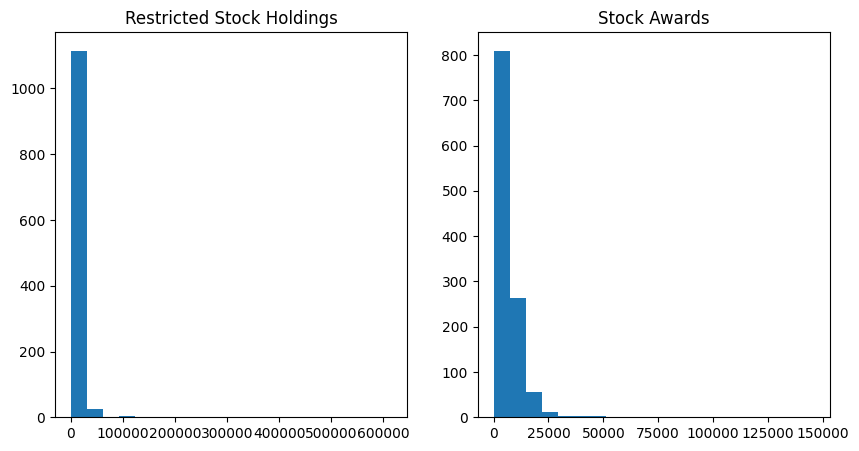

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(stock_query['stock_unvest_val'], bins=20)
plt.title('Restricted Stock Holdings')


plt.subplot(1,2,2)
plt.hist(stock_query['stock_awards'], bins=20)
plt.title('Stock Awards')


print(stock_query['stock_awards'].describe())
print(stock_query['stock_unvest_val'].describe())

In order to normalize this data, I will exclude outliers which will be values that are 1.5*IQR above quartile 3 and below quartile 1.

In [ ]:
q1_unvest_outlier = stock_query['stock_unvest_val'].quantile(0.25)
q3_unvest_outlier = stock_query['stock_unvest_val'].quantile(0.75)
iqr_unvest_outlier = q3_unvest_outlier - q1_unvest_outlier
upper_unvest_utlier = q3_unvest_outlier + 1.5*iqr_unvest_outlier
lower_unvest_outlier = q1_unvest_outlier - 1.5*iqr_unvest_outlier


q1_stock_outlier = stock_query['stock_unvest_val'].quantile(0.25)
q3_stock_outlier = stock_query['stock_unvest_val'].quantile(0.75)
iqr_stock_outlier = q3_stock_outlier - q1_stock_outlier
upper_stock_utlier = q3_stock_outlier + 1.5*iqr_stock_outlier
lower_stock_outlier = q1_stock_outlier - 1.5*iqr_stock_outlier


stock_query = stock_query[((stock_query['stock_unvest_val'] <= upper_unvest_utlier) & (stock_query['stock_unvest_val'] >= lower_unvest_outlier)) &
              ((stock_query['stock_awards'] <= upper_stock_utlier) & (stock_query['stock_awards'] >= lower_stock_outlier))]


print(stock_query['stock_awards'].describe())
print(stock_query['stock_unvest_val'].describe())

count      996.000000
mean      4568.192353
std       3507.607394
min          0.000000
25%       1769.900750
50%       3998.954000
75%       6736.328250
max      14625.000000
Name: stock_awards, dtype: float64
count      996.00000
mean      3524.23757
std       3644.81792
min          0.00000
25%        200.10300
50%       2430.22200
75%       5678.02900
max      14335.24900
Name: stock_unvest_val, dtype: float64


Text(0.5, 1.0, 'Stock Awards')

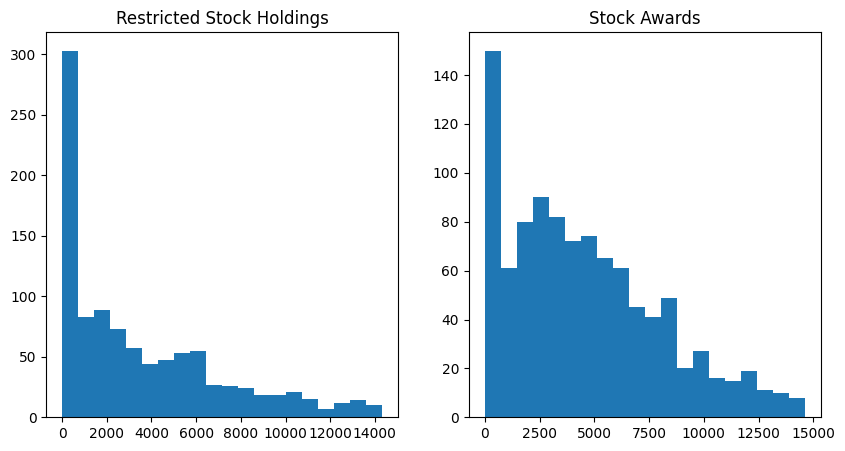

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(stock_query['stock_unvest_val'], bins=20)
plt.title('Restricted Stock Holdings')


plt.subplot(1,2,2)
plt.hist(stock_query['stock_awards'], bins=20)
plt.title('Stock Awards')


After removing outliers, I will create scatterplots with a linear regression line to better understand the correlation of these different variables.

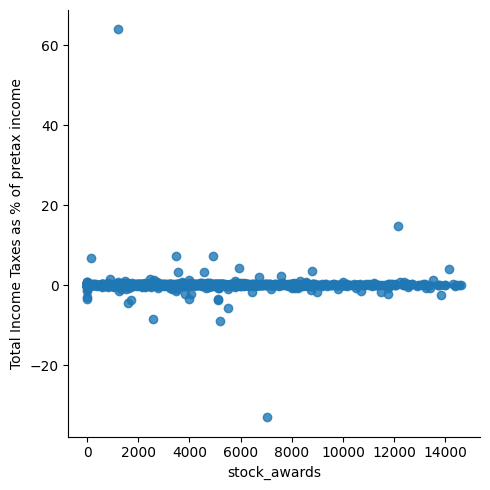

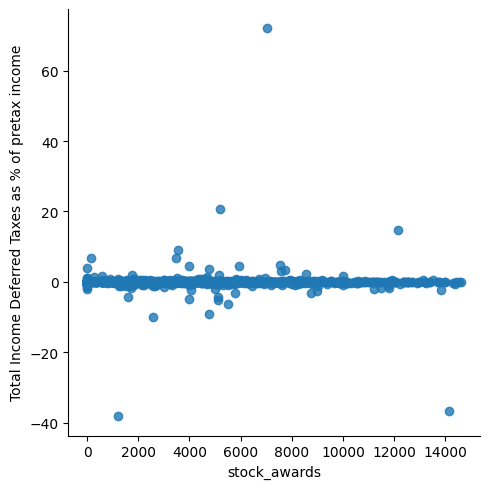

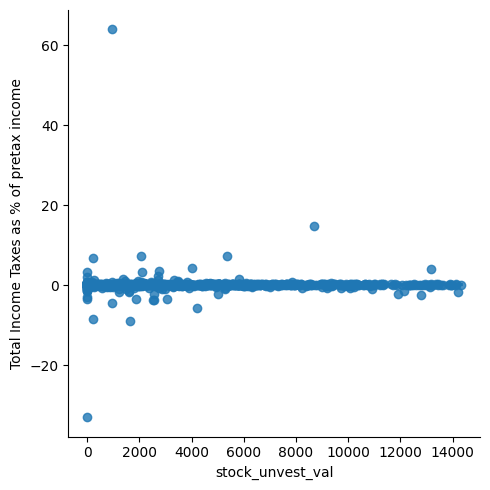

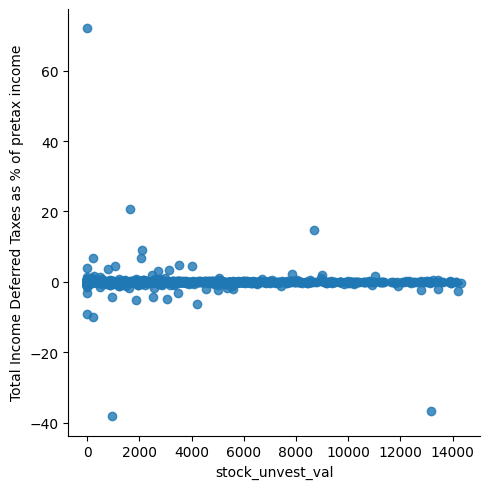

In [ ]:
sns.lmplot(x='stock_awards', y='Total Income Taxes as % of pretax income', data=stock_query)
sns.lmplot(x='stock_awards', y='Total Income Deferred Taxes as % of pretax income', data=stock_query)

sns.lmplot(x='stock_unvest_val', y='Total Income Taxes as % of pretax income', data=stock_query)
sns.lmplot(x='stock_unvest_val', y='Total Income Deferred Taxes as % of pretax income', data=stock_query)


Now that we have visualized the relationshps between stocks and taxes, I will now take a closer look at the actual regression summary to understand what these correlations look like.

In [ ]:
# Regression Analysis for Stock Awards vs. Total Income Taxes as % of pretax income
x = stock_query['stock_awards']
y = stock_query['Total Income Taxes as % of pretax income']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                                       OLS Regression Results                                       
Dep. Variable:     Total Income Taxes as % of pretax income   R-squared:                       0.000
Model:                                                  OLS   Adj. R-squared:                 -0.001
Method:                                       Least Squares   F-statistic:                    0.3228
Date:                                      Sun, 13 Apr 2025   Prob (F-statistic):              0.570
Time:                                              20:10:18   Log-Likelihood:                -2307.4
No. Observations:                                       996   AIC:                             4619.
Df Residuals:                                           994   BIC:                             4629.
Df Model:                                                 1                                         
Covariance Type:                                  nonrobust                                

In [ ]:
# Regression Analysis for Stock Awards vs. Total Income Deferred Taxes as % of pretax income
x = stock_query['stock_awards']
y = stock_query['Total Income Deferred Taxes as % of pretax income']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())


                                            OLS Regression Results                                           
Dep. Variable:     Total Income Deferred Taxes as % of pretax income   R-squared:                       0.000
Model:                                                           OLS   Adj. R-squared:                 -0.001
Method:                                                Least Squares   F-statistic:                  0.005756
Date:                                               Sun, 13 Apr 2025   Prob (F-statistic):              0.940
Time:                                                       20:10:45   Log-Likelihood:                -2531.5
No. Observations:                                                996   AIC:                             5067.
Df Residuals:                                                    994   BIC:                             5077.
Df Model:                                                          1                                         
Covariance

In [ ]:
# Regression Analysis for Restricted Holdings vs. Total Income Taxes as % of pretax income
x = stock_query['stock_unvest_val']
y = stock_query['Total Income Taxes as % of pretax income']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())


                                       OLS Regression Results                                       
Dep. Variable:     Total Income Taxes as % of pretax income   R-squared:                       0.000
Model:                                                  OLS   Adj. R-squared:                 -0.001
Method:                                       Least Squares   F-statistic:                   0.02309
Date:                                      Sun, 13 Apr 2025   Prob (F-statistic):              0.879
Time:                                              20:10:48   Log-Likelihood:                -2307.5
No. Observations:                                       996   AIC:                             4619.
Df Residuals:                                           994   BIC:                             4629.
Df Model:                                                 1                                         
Covariance Type:                                  nonrobust                                

In [ ]:
# Regression Analysis for Restricted Holdings vs. Total Income Deferred Taxes as % of pretax income
x = stock_query['stock_unvest_val']
y = stock_query['Total Income Deferred Taxes as % of pretax income']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())


                                            OLS Regression Results                                           
Dep. Variable:     Total Income Deferred Taxes as % of pretax income   R-squared:                       0.002
Model:                                                           OLS   Adj. R-squared:                  0.001
Method:                                                Least Squares   F-statistic:                     2.254
Date:                                               Sun, 13 Apr 2025   Prob (F-statistic):              0.134
Time:                                                       20:10:50   Log-Likelihood:                -2530.4
No. Observations:                                                996   AIC:                             5065.
Df Residuals:                                                    994   BIC:                             5075.
Df Model:                                                          1                                         
Covariance